In [2]:
import pandas as pd
import re
import time
from deep_translator import GoogleTranslator
import nltk
from nltk.corpus import stopwords

In [ ]:
# load dataset
df = pd.read_csv("dataset.csv")

# cek data
print(df.head())
print(df.columns)
print(len(df))


                                              Posisi  \
0  Manager - IFS - Entrepreneurial and Private Bu...   
1   Region Merchant Partnership & Activation Manager   
2                     Supply Strategy Senior Manager   
3                                   Commis I25137114   
4                             Fleet Management Staff   

                    Perusahaan           Lokasi       Type Gaji  \
0                PwC Indonesia     Jakarta Raya  Full time  NaN   
1  PT GOTO GOJEK TOKOPEDIA TBK            Medan  Full time  NaN   
2  PT GOTO GOJEK TOKOPEDIA TBK     Jakarta Raya  Full time  NaN   
3    Sheraton Bali Kuta Resort  Bangka Belitung  Full time  NaN   
4             Kawan Lama Group         Denpasar  Full time  NaN   

                                        Requirements  \
0  Analyse and identify the linkages and interact...   
1  Analyze market dynamics, monitor competitor ac...   
2  Lead the end-to-end supply strategy for Gojek ...   
3                                   

In [126]:
df.shape

(4901, 7)

In [127]:
df.isna().sum()

Posisi             0
Perusahaan         4
Lokasi             0
Type             182
Gaji            3233
Requirements     711
Link               0
dtype: int64

In [128]:
df = df.dropna(subset=["Requirements"])
df["Gaji"] = df["Gaji"].fillna("-")
df["Type"] = df["Type"].fillna("-")
df["Perusahaan"] = df["Perusahaan"].fillna("-")

df.isna().sum()

Posisi          0
Perusahaan      0
Lokasi          0
Type            0
Gaji            0
Requirements    0
Link            0
dtype: int64

# MINI PREPRO

In [ ]:
def clean_text(text):
    text = text.lower()
    
    # hapus angka (opsional)
    text = re.sub(r'\d+', ' ', text)
    
    # hapus simbol
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

df["text"] = (
    df["Posisi"].fillna("") + " " + 
    df["Posisi"].fillna("") + " " + 
    df["Requirements"].fillna("")
)
df["text"] = df["text"].apply(clean_text)
df

,Posisi,Perusahaan,Lokasi,Type,Gaji,Requirements,Link,text
0,Manager - IFS - Entrepreneurial and Private Bu...,PwC Indonesia,Jakarta Raya,Full time,-,Analyse and identify the linkages and interact...,https://id.jobstreet.com/id/job/87240744?type=...,manager ifs entrepreneurial and private busine...
1,Region Merchant Partnership & Activation Manager,PT GOTO GOJEK TOKOPEDIA TBK,Medan,Full time,-,"Analyze market dynamics, monitor competitor ac...",https://id.jobstreet.com/id/job/87400339?type=...,region merchant partnership activation manager...
2,Supply Strategy Senior Manager,PT GOTO GOJEK TOKOPEDIA TBK,Jakarta Raya,Full time,-,Lead the end-to-end supply strategy for Gojek ...,https://id.jobstreet.com/id/job/87400340?type=...,supply strategy senior manager supply strategy...
4,Fleet Management Staff,Kawan Lama Group,Denpasar,Full time,-,Usia maksimal 35 tahun.; Pendidikan minimal SM...,https://id.jobstreet.com/id/job/87234032?type=...,fleet management staff fleet management staff ...
5,Sales (live Streaming),Kawan Lama Group,Kecamatan Tangerang,Full time,-,Pendidikan minimal D3/S1 segala jurusan.; Akti...,https://id.jobstreet.com/id/job/87234040?type=...,sales live streaming sales live streaming pend...
...,...,...,...,...,...,...,...,...
4894,Accounting And Tax,PT Triyuda Perkasa,Kabupaten Mojokerto,Full time,-,Pendidikan minimal /DIII/S1 jurusan Akuntansi;...,https://id.jobstreet.com/id/job/91221267?type=...,accounting and tax accounting and tax pendidik...
4895,Strategic Procurement Officer,PT Mandom Indonesia Tbk,Cibitung,Full time,-,Conduct strategic analysis on raw material pri...,https://id.jobstreet.com/id/job/91444417?type=...,strategic procurement officer strategic procur...
4896,Supervisor RnD Mikrobiologi,PT Erlimpex,Semarang,Full time,-,Pendidikan S1 Mikrobiologi; Fresh graduate / m...,https://id.jobstreet.com/id/job/91598056?type=...,supervisor rnd mikrobiologi supervisor rnd mik...
4897,Cylinder Control Staff,PT. Geoservices,Cileungsi,-,-,Manage and update real-time cylinder stock dat...,https://id.jobstreet.com/id/job/91450386?type=...,cylinder control staff cylinder control staff ...


# BALANCING

In [130]:
categories = {

    "Data": [
        "data analyst", "data analytics", "data scientist", "data science",
        "machine learning", "ml engineer", "deep learning", "ai engineer",
        "data engineer", "big data", "data mining", "data visualization",
        "analisis data", "ilmuwan data", "pengolahan data","data"
    ],

    "Software": [
        "software engineer", "software developer", "developer", "programmer",
        "backend", "backend developer", "frontend", "frontend developer",
        "full stack", "fullstack", "web developer", "mobile developer","web","api","mobile",
        "android developer", "ios developer", "pengembang", "coding", "komputer","computer"
    ],

    "Marketing": [
        "marketing", "digital marketing", "seo", "sem", "content marketing",
        "branding", "social media", "campaign", "market research",
        "pemasaran", "iklan", "advertising"
    ],

    "Finance": [
        "finance", "financial", "accounting", "accountant", "tax", "auditor",
        "budgeting", "investment", "banking", "keuangan", "akuntansi",
        "pajak", "audit","penagihan","collection"
    ],

    "HR": [
        "hr", "human resource", "recruitment", "recruiter",
        "talent acquisition", "people development", "training",
        "sumber daya manusia", "rekrutmen", "hrd"
    ],

    "Design & Creative": [
        "ui", "ux", "ui ux", "ui/ux", "product design",
        "graphic design", "graphic designer", "visual design",
        "creative design", "desain grafis", "desainer",
        "videographer", "photographer", "editor","kreatif",
        "content creator", "tiktok", "media","design",
        "creative", "social media content","live"
    ],

    "Operations": [
        "operations", "operational", "operation staff","inventory","stock","display",
        "logistics", "supply chain", "warehouse", "inventory",
        "procurement", "purchasing", "gudang","supervisor","k3","keselamatan kerja"
    ],

    "Sales": [
        "sales", "sales executive", "account manager",
        "business development", "bd", "client relation",
        "penjualan", "sales marketing", "consultant","account executive"
    ],

    "Engineering": [
        "engineer", "engineering", "mechanical", "electrical","prototipe","architect","arsitek",
        "civil", "industrial engineer", "teknik mesin","proses produksi","drilling","teknik industri",
        "teknik sipil", "teknik elektro","elektro","listrik","mekanik","alat berat"
    ],

    "Customer Service": [
        "customer service", "customer support", "support",
        "call center", "helpdesk", "cs", "layanan pelanggan","service"
    ],
    "Admin": [
        "admin", "administration", "administrasi", "asisten",
        "secretary", "sekretaris", "dokumen","document",
        "assistant", "personal assistant","document controller","legal"
    ],

    "Hospitality": [
        "hotel", "waiter", "waitress", "barista", "chef", "supir","sopir","pelayan","pelayanan",
        "kitchen", "restaurant", "f&b", "food", "beverage","masak","memasak",
        "front office", "guest service", "housekeeping","baker","driver","pembantu","tamu"
    ],

    "Healthcare": [
        "perawat", "nurse", "kesehatan", "medical","medis","gizi","ahli gizi","mental","psikiater","psikolog",
        "lab", "bioteknologi", "farmasi","medic","healthcare","dokter","apotek","safety"
    ],

    "Education": [
        "guru", "teacher", "school", "walikelas", "mengajar","pengajar","pelajaran", "les",
        "dosen", "education", "anak", "pendidikan", "pengajar","siswa","kelas","sekolah"
    ],

    "Other": []
}


In [131]:
def classify_job(text):
    scores = {}

    for category, keywords in categories.items():
        score = 0
        for keyword in keywords:
            if keyword in text:
                # keyword panjang lebih kuat
                score += 2 if len(keyword.split()) > 1 else 1
        scores[category] = score

    best_category = max(scores, key=scores.get)

    if scores[best_category] == 0:
        return "Other"

    return best_category

In [132]:
df["Category"] = df["text"].apply(classify_job)

# lihat hasil
print(df[["Posisi", "Category"]].head())


                                              Posisi    Category
0  Manager - IFS - Entrepreneurial and Private Bu...     Finance
1   Region Merchant Partnership & Activation Manager  Operations
2                     Supply Strategy Senior Manager  Operations
4                             Fleet Management Staff   Education
5                             Sales (live Streaming)   Marketing


In [133]:
print(df["Category"].value_counts())


Category
Finance              647
Engineering          525
Operations           436
Sales                408
Marketing            375
Design & Creative    359
Admin                275
Data                 217
Education            208
Software             186
Customer Service     170
HR                   161
Healthcare           114
Hospitality          101
Other                  8
Name: count, dtype: int64


In [ ]:
# 1. buang Other
df_filtered = df[df["Category"] != "Other"].copy()

# 2. buat flag salary
df_filtered["has_salary"] = df_filtered["Gaji"].fillna("").astype(str).str.strip() != "-"

# 3. fungsi sampling per kategori
def smart_sample(group):
    # prioritas 1: ada gaji
    with_salary = group[group["has_salary"] == True]
    
    # prioritas 2: tanpa gaji
    without_salary = group[group["has_salary"] == False]
    
    # ambil dulu yang ada gaji
    result = with_salary.head(100)
    
    # kalau belum cukup, tambah yang tanpa gaji
    if len(result) < 100:
        remaining = 100 - len(result)
        result = pd.concat([result, without_salary.head(remaining)])
    
    return result

# 4. apply per kategori
df_balanced = (
    df_filtered
    .groupby("Category", group_keys=False)
    .apply(smart_sample)
    .reset_index(drop=True)
)

# 5. cek hasil
print(df_balanced["Category"].value_counts())

Category
Admin                100
Customer Service     100
Data                 100
Design & Creative    100
Education            100
Engineering          100
Finance              100
HR                   100
Healthcare           100
Hospitality          100
Marketing            100
Operations           100
Sales                100
Software             100
Name: count, dtype: int64


C:\Users\acer\AppData\Local\Temp\ipykernel_19596\3989281639.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(smart_sample)


In [135]:
df_balanced.to_csv("dataset_balanced.csv", index=False)

In [136]:
dfb = pd.read_csv("dataset_balanced.csv")

# cek data
print(df.head())
print(df.columns)
print(len(df))

                                              Posisi  \
0  Manager - IFS - Entrepreneurial and Private Bu...   
1   Region Merchant Partnership & Activation Manager   
2                     Supply Strategy Senior Manager   
4                             Fleet Management Staff   
5                             Sales (live Streaming)   

                    Perusahaan               Lokasi       Type Gaji  \
0                PwC Indonesia         Jakarta Raya  Full time    -   
1  PT GOTO GOJEK TOKOPEDIA TBK                Medan  Full time    -   
2  PT GOTO GOJEK TOKOPEDIA TBK         Jakarta Raya  Full time    -   
4             Kawan Lama Group             Denpasar  Full time    -   
5             Kawan Lama Group  Kecamatan Tangerang  Full time    -   

                                        Requirements  \
0  Analyse and identify the linkages and interact...   
1  Analyze market dynamics, monitor competitor ac...   
2  Lead the end-to-end supply strategy for Gojek ...   
4  Usia maks

In [ ]:
translated_texts = []

def translate_text(text):
    try:
        if text is None or str(text).strip() == "":
            return text
        
        # Indonesia → English
        return GoogleTranslator(source="auto", target="en").translate(text)
    
    except Exception as e:
        print(f"Error: {e}")
        return text  # fallback

# proses translate
for i, text in enumerate(dfb["text"]):
    print(f"Translating {i+1}/{len(dfb)}...")
    
    translated = translate_text(text)
    translated_texts.append(translated)
    
    time.sleep(0.5)  # antisipasi limit API

print("✅ Translate selesai")

Translating 1/1400...
Translating 2/1400...
Translating 3/1400...
Translating 4/1400...
Translating 5/1400...
Translating 6/1400...
Translating 7/1400...
Translating 8/1400...
Translating 9/1400...
Translating 10/1400...
Translating 11/1400...
Translating 12/1400...
Translating 13/1400...
Translating 14/1400...
Translating 15/1400...
Translating 16/1400...
Translating 17/1400...
Translating 18/1400...
Translating 19/1400...
Translating 20/1400...
Translating 21/1400...
Translating 22/1400...
Translating 23/1400...
Translating 24/1400...
Translating 25/1400...
Error: site csr superintendent site csr superintendent menyusun strategi rencana kerja dan program csr tahunan maupun jangka menengah panjang sesuai arah kebijakan perusahaan melakukan pemetaan kebutuhan sosial masyarakat sekitar wilayah operasional perusahaan menyusun prioritas program csr berdasarkan aspek sosial ekonomi pendidikan kesehatan lingkungan pemberdayaan masyarakat dan keberlanjutan memastikan program csr selaras deng

In [140]:
dfb["translated_text"] = translated_texts
dfb[["text", "translated_text"]]

,text,translated_text
0,tenaga admin tenaga admin pekerjaan administra...,admin staff admin staff general administrative...
1,admin operasional hr support magang admin oper...,Admin Operational HR Support Internship Admin ...
2,executive admin executive admin mengelola kale...,executive admin executive admin manages execut...
3,executive admin executive admin mengelola jadw...,executive admin executive admin manages meetin...
4,operations admin coordinator indonesia represe...,operations admin coordinator Indonesia represe...
...,...,...
1395,staff dokumen staff dokumen pendidikan min d i...,document staff document staff education min d ...
1396,chatime staff timika papua chatime staff timik...,chatime staff Timika Papua chatime staff Timik...
1397,road to market specialist road to market speci...,road to market specialist road to market speci...
1398,research and development staff kosmetik skinca...,research and development staff skincare cosmet...


In [ ]:
# download sekali saja
nltk.download('stopwords')

# load stopwords english
stop_words = set(stopwords.words('english'))

# optional: tambahkan stopwords khusus job (biar lebih clean)
custom_stopwords = {
    "job", "requirement", "requirements", "responsibilities",
    "experience", "skill", "skills", "ability", "abilities",
    "candidate", "position", "role"
}

stop_words = stop_words.union(custom_stopwords)

# fungsi cleaning + stopword removal
def clean_text(text):
    text = str(text).lower()
    
    # hapus simbol
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    
    # hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    
    # tokenisasi + hapus stopwords
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    
    return " ".join(tokens)

# apply ke kolom translated_text
dfb["clean_text"] = dfb["translated_text"].apply(clean_text)

# cek hasil
dfb[["translated_text", "clean_text"]].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,translated_text,clean_text
0,admin staff admin staff general administrative...,admin staff admin staff general administrative...
1,Admin Operational HR Support Internship Admin ...,admin operational hr support internship admin ...
2,executive admin executive admin manages execut...,executive admin executive admin manages execut...
3,executive admin executive admin manages meetin...,executive admin executive admin manages meetin...
4,operations admin coordinator Indonesia represe...,operations admin coordinator indonesia represe...


In [149]:
dfb.drop(columns=["has_salary"]).to_csv("data_clean.csv", index=False)

# EDA

In [13]:
df = pd.read_csv("data_clean.csv")
df

,Posisi,Perusahaan,Lokasi,Type,Gaji,Requirements,Link,text,Category,translated_text,clean_text
0,Tenaga Admin,PT Serdang Baja Makmur Abadi,Medan,Full time,Rp 3.250.000 – Rp 3.500.000 per month,Pekerjaan administrasi umum seperti membuat In...,https://id.jobstreet.com/id/job/91338594?type=...,tenaga admin tenaga admin pekerjaan administra...,Admin,admin staff admin staff general administrative...,admin staff admin staff general administrative...
1,Admin Operasional & HR Support (MAGANG),PT Saptakarsa Prima,Kecamatan Tangerang,Full time,Rp 2.500.000 – Rp 3.500.000 per month,Pendidikan minimal SMK Jurusan Administrasi Pe...,https://id.jobstreet.com/id/job/91309622?type=...,admin operasional hr support magang admin oper...,Admin,Admin Operational HR Support Internship Admin ...,admin operational hr support internship admin ...
2,Executive admin,Pengiklan Anonim,Jakarta Utara,Full time,Rp 4.700.000 – Rp 5.500.000 per month,Mengelola kalender dan jadwal eksekutif dengan...,https://id.jobstreet.com/id/job/91479903?type=...,executive admin executive admin mengelola kale...,Admin,executive admin executive admin manages execut...,executive admin executive admin manages execut...
3,Executive admin,Pengiklan Anonim,Jakarta Utara,Full time,Rp 4.700.000 – Rp 5.500.000 per month,"Mengelola jadwal, pertemuan, dan kegiatan ekse...",https://id.jobstreet.com/id/job/91508884?type=...,executive admin executive admin mengelola jadw...,Admin,executive admin executive admin manages meetin...,executive admin executive admin manages meetin...
4,Operations & Admin Coordinator (Indonesia Repr...,Pengiklan Anonim,Cilandak,Full time,Rp 6.500.000 – Rp 8.500.000 per month,Manage daily administrative tasks; Organize do...,https://id.jobstreet.com/id/job/91487019?type=...,operations admin coordinator indonesia represe...,Admin,operations admin coordinator Indonesia represe...,operations admin coordinator indonesia represe...
...,...,...,...,...,...,...,...,...,...,...,...
1395,Staff Dokumen,PT Uniair Indotama Cargo,Batam,Full time,-,Pendidikan Min. D-4 Ilmu Transportasi Logistik...,https://id.jobstreet.com/id/job/91344787?type=...,staff dokumen staff dokumen pendidikan min d i...,Software,document staff document staff education min d ...,document staff document staff education min ma...
1396,Chatime Staff - Timika (Papua),PT Foods Beverages Indonesia,Timika,Full time,-,Menyambut dan melayani pelanggan dengan ramah ...,https://id.jobstreet.com/id/job/91510593?type=...,chatime staff timika papua chatime staff timik...,Software,chatime staff Timika Papua chatime staff Timik...,chatime staff timika papua chatime staff timik...
1397,Road To Market Specialist,PT Tirta Utama Abadi,Bandung,Full time,-,"Melakukan perencanaan, identifikasi dan analis...",https://id.jobstreet.com/id/job/91591887?type=...,road to market specialist road to market speci...,Software,road to market specialist road to market speci...,road market specialist road market specialist ...
1398,Research and Development Staff (Kosmetik & Ski...,PT Glow Industri Herbal Care,Cikarang,Kontrak/Temporer,-,Pendidikan minimal D3 Farmasi/ Kimia; Memiliki...,https://id.jobstreet.com/id/job/91458996?type=...,research and development staff kosmetik skinca...,Software,research and development staff skincare cosmet...,research development staff skincare cosmetics ...


## PREPROCESSING UNTUK MODEL EMBENDING

In [14]:
def preprocess_embed(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", " ", text)      # hapus tanda baca
    text = re.sub(r"\s+", " ", text).strip()
    return text

# untuk embedding dengan punctuation
def preprocess_embed_punct(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

def remove_duplicate(text, preprocess_func):

    # preprocess dulu
    text = preprocess_func(text)

    words = text.split()

    # cek kemungkinan posisi 1-10 kata
    for n in range(1, min(10, len(words)//2) + 1):

        first_part = words[:n]
        second_part = words[n:n*2]

        # kalau sama → hapus satu
        if first_part == second_part:
            return " ".join(words[n:])

    return text

df.rename(
    columns={
        "clean_text": "text_for_tfidf"
    },
    inplace=True
)

# embedding tanpa punctuation
df["text_for_embed"] = df["translated_text"].apply(
    lambda x: remove_duplicate(x, preprocess_embed)
)

# embedding dengan punctuation
df["text_for_embed_with_punctuation"] = df["translated_text"].apply(
    lambda x: remove_duplicate(x, preprocess_embed_punct)
)

final_df = df[
    [
        "Posisi",
        "Perusahaan",
        "Lokasi",
        "Type",
        "Gaji",
        "Requirements",
        "Link",
        "text_for_tfidf",
        "text_for_embed",
        "text_for_embed_with_punctuation"
    ]
]

# save overwrite
final_df.to_csv("data_clean.csv", index=False)

print("✅ CSV berhasil diupdate")
print(final_df.head())

✅ CSV berhasil diupdate
                                              Posisi  \
0                                       Tenaga Admin   
1            Admin Operasional & HR Support (MAGANG)   
2                                    Executive admin   
3                                    Executive admin   
4  Operations & Admin Coordinator (Indonesia Repr...   

                     Perusahaan               Lokasi       Type  \
0  PT Serdang Baja Makmur Abadi                Medan  Full time   
1           PT Saptakarsa Prima  Kecamatan Tangerang  Full time   
2              Pengiklan Anonim        Jakarta Utara  Full time   
3              Pengiklan Anonim        Jakarta Utara  Full time   
4              Pengiklan Anonim             Cilandak  Full time   

                                    Gaji  \
0  Rp 3.250.000 – Rp 3.500.000 per month   
1  Rp 2.500.000 – Rp 3.500.000 per month   
2  Rp 4.700.000 – Rp 5.500.000 per month   
3  Rp 4.700.000 – Rp 5.500.000 per month   
4  Rp 6.500.000 

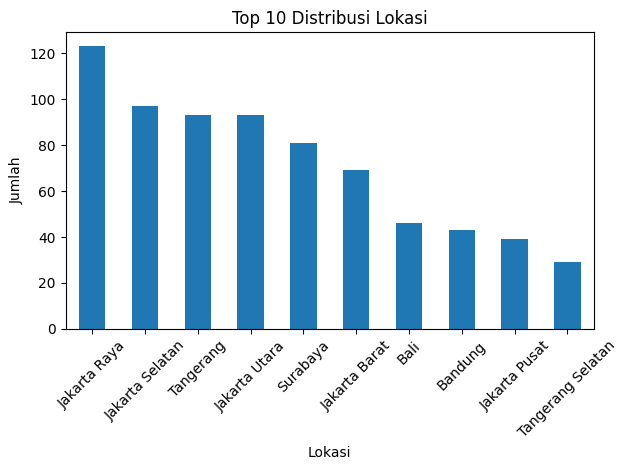

In [5]:
import matplotlib.pyplot as plt

# Hitung top 10 lokasi
top_locations = df["Lokasi"].value_counts().head(10)

# Plot
plt.figure()
top_locations.plot(kind="bar")

plt.title("Top 10 Distribusi Lokasi")
plt.xlabel("Lokasi")
plt.ylabel("Jumlah")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

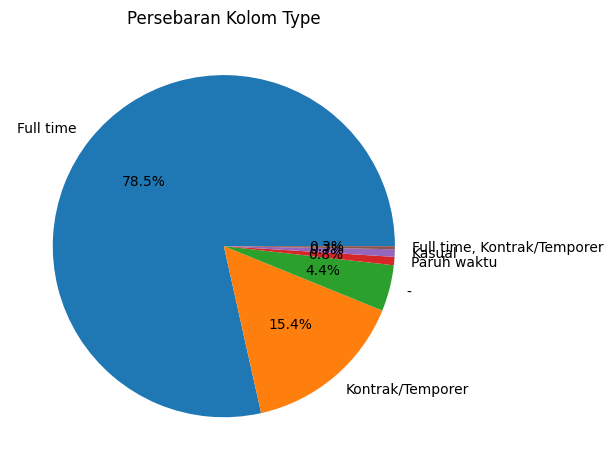

In [6]:
type_counts = df["Type"].value_counts()

plt.figure()
plt.pie(type_counts, labels=type_counts.index, autopct="%1.1f%%")
plt.title("Persebaran Kolom Type")
plt.tight_layout()
plt.show()

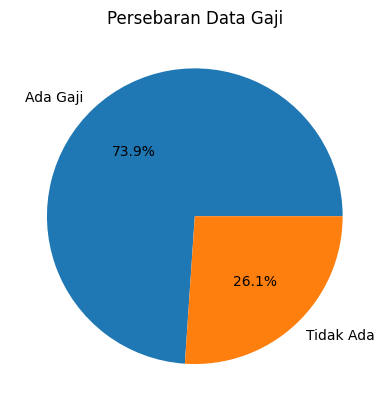

In [10]:

# Buat kategori
gaji_status = df["Gaji"].apply(lambda x: "Ada Gaji" if x != "-" else "Tidak Ada")

# Hitung jumlah
gaji_counts = gaji_status.value_counts()

# Plot pie chart
plt.figure()
plt.pie(gaji_counts, labels=gaji_counts.index, autopct="%1.1f%%")

plt.title("Persebaran Data Gaji")

plt.show()